In [1]:
#import library
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download required nltk data
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/anthony/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/anthony/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/anthony/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [2]:
# load the dataset
df = pd.read_csv("../datasets/IMDB_Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
#basic data inspection
#shape
df.shape


(50000, 2)

In [4]:
#column name
df.columns

Index(['review', 'sentiment'], dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 63.6 MB


In [6]:
# check null values
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [7]:

df["sentiment"].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [8]:
df["sentiment"] = (
    df["sentiment"]
    .str.capitalize()
)

In [9]:
df["domain"] = "movie"

In [10]:
def sentiment_to_rating(sentiment):

    if sentiment == "Positive":
        return 8

    else:
        return 2
    
df["rating"] = (
    df["sentiment"]
    .apply(sentiment_to_rating)
)

In [11]:
df["review_length"] = (
    df["review"].apply(len)
)

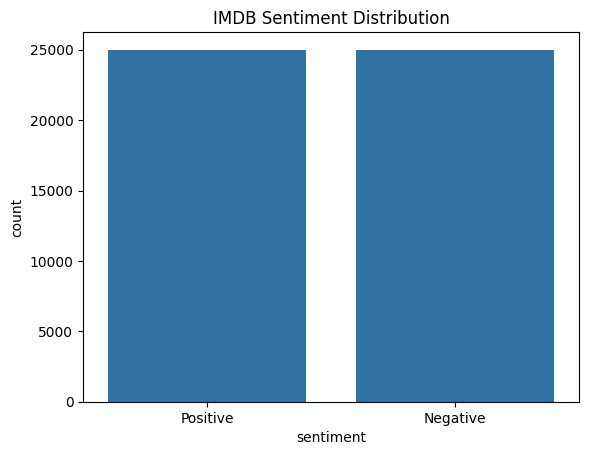

In [12]:
sns.countplot(
    x="sentiment",
    data=df
)

plt.title(
    "IMDB Sentiment Distribution"
)

plt.show()

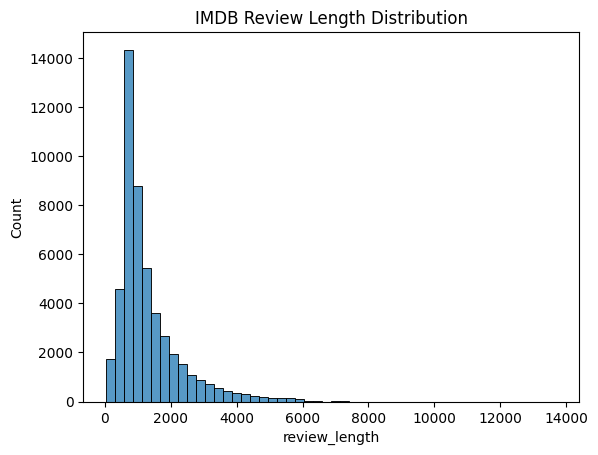

In [13]:
sns.histplot(
    df["review_length"],
    bins=50
)

plt.title(
    "IMDB Review Length Distribution"
)

plt.show()

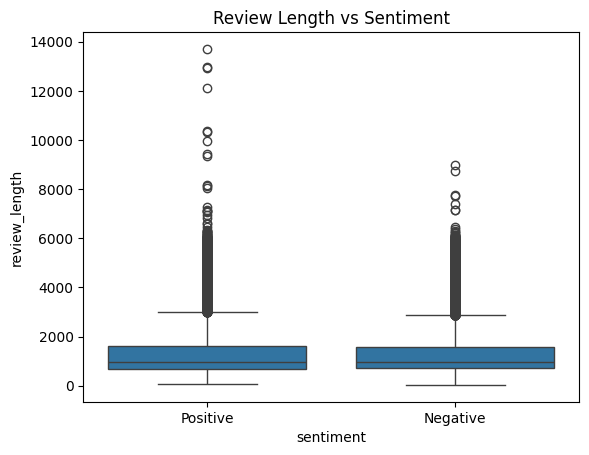

In [14]:
sns.boxplot(
    x="sentiment",
    y="review_length",
    data=df
)

plt.title(
    "Review Length vs Sentiment"
)

plt.show()

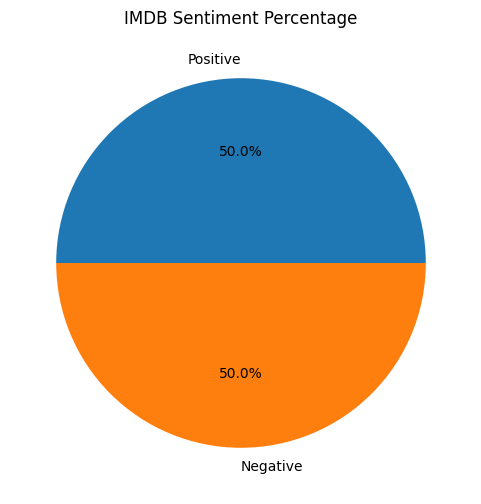

In [15]:
df["sentiment"].value_counts().plot.pie(
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title(
    "IMDB Sentiment Percentage"
)

plt.ylabel("")

plt.show()

In [16]:
from collections import Counter

In [17]:
all_words = " ".join(
    df["review"]
).split()

In [18]:
common_words = Counter(
    all_words
).most_common(20)

In [19]:
common_df = pd.DataFrame(
    common_words,
    columns=["word", "count"]
)

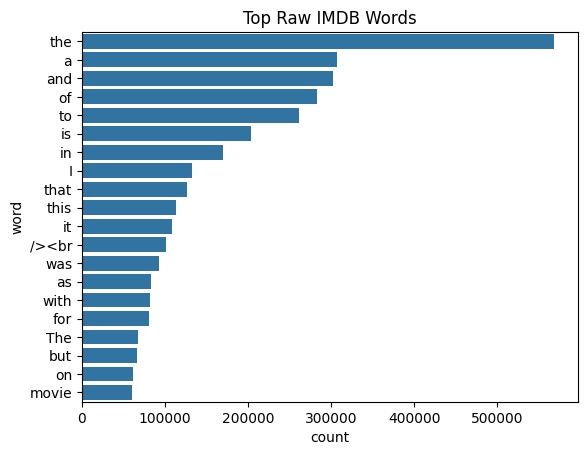

In [20]:
sns.barplot(
    x="count",
    y="word",
    data=common_df
)

plt.title(
    "Top Raw IMDB Words"
)

plt.show()

In [23]:
#create stop word and lemmatizer
stop_words = set(
    stopwords.words("english")
)

important_negations = {
    "not",
    "no",
    "nor",
    "never"
}

stop_words = stop_words - important_negations
lemmatizer = WordNetLemmatizer()

In [24]:
def clean_text(text):

    # lowercase
    text = text.lower()

    # remove urls
    text = re.sub(r"http\S+", " ", text)

    # remove html tags
    text = re.sub(r"<.*?>", " ", text)

    # remove numbers
    text = re.sub(r"\d+", " ", text)

    # remove punctuation/special chars
    text = re.sub(
        r"[^a-zA-Z\s]",
        " ",
        text
    )

    # remove extra spaces
    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    # tokenize
    words = text.split()

    # stopword removal + lemmatization
    words = [

        lemmatizer.lemmatize(word)

        for word in words

        if word not in stop_words
        and len(word) > 2
    ]

    return " ".join(words)

In [25]:
df["clean_review"] = (
    df["review"]
    .apply(clean_text)
)

In [26]:
df[
    ["review", "clean_review"]
].head()

,review,clean_review
0,One of the other reviewers has mentioned that ...,one reviewer mentioned watching episode hooked...
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,basically family little boy jake think zombie ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei love time money visually stunnin...


In [27]:
from wordcloud import WordCloud


In [28]:
text = " ".join(
    df["clean_review"]
)

In [29]:
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(text)

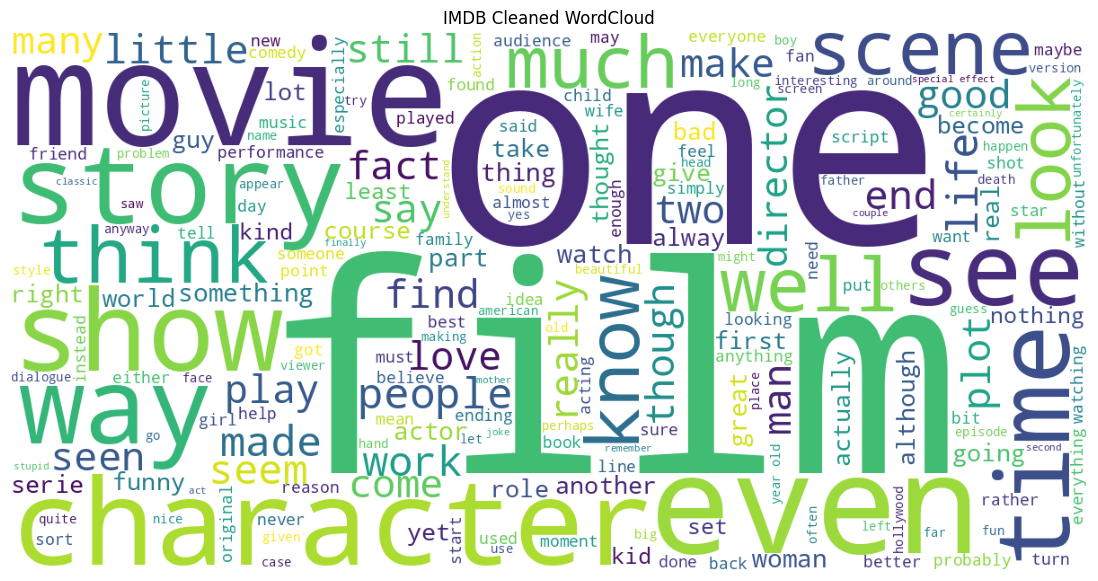

In [30]:
plt.figure(figsize=(15,7))

plt.imshow(wordcloud)

plt.axis("off")

plt.title(
    "IMDB Cleaned WordCloud"
)

plt.show()

In [31]:
df = df[
    df["clean_review"] != ""
]

In [32]:
from collections import Counter

In [33]:
all_words = " ".join(
    df["clean_review"]
).split()

In [34]:
common_words = Counter(
    all_words
).most_common(20)

In [35]:
common_df = pd.DataFrame(
    common_words,
    columns=["word", "count"]
)

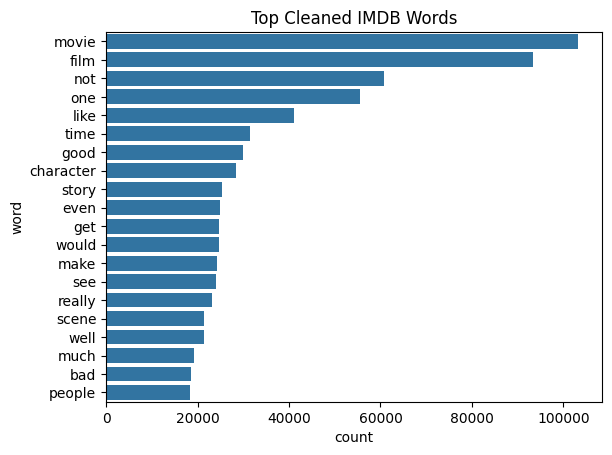

In [36]:
sns.barplot(
    x="count",
    y="word",
    data=common_df
)

plt.title(
    "Top Cleaned IMDB Words"
)

plt.show()

In [37]:
df.to_csv(
    "../processed_data/imdb_processed.csv",
    index=False
)

In [38]:
df.columns

Index(['review', 'sentiment', 'domain', 'rating', 'review_length',
       'clean_review'],
      dtype='str')